In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.applications import VGG16

In [8]:
# ================================
# PARAMETERS
# ================================
img_size = 224
batch_size = 32
epochs = 10

In [9]:
# ================================
# DATA PREPROCESSING + AUGMENTATION
# ================================
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [10]:
import os
from pathlib import Path

# Ensure relative paths like "brain_tumor_dataset" resolve from the project root.
if Path.cwd().name == "Case Study 3":
    os.chdir(Path.cwd().parent)
print("Current working directory:", Path.cwd())

Current working directory: c:\Users\mishr\OneDrive\Desktop\DL LAB


In [11]:
# TRAIN DATA
train_generator = datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

Found 203 images belonging to 2 classes.


In [12]:
# VALIDATION DATA
val_generator = datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

Found 50 images belonging to 2 classes.


In [21]:
# =========================================
# CNN MODEL
# Modified Architecture + Regularization
# =========================================
model = models.Sequential([

    layers.Conv2D(32,(3,3),padding="same",input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64,(3,3),padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1,activation="sigmoid")
])

c:\Users\mishr\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# =========================================
# TRAIN WITH ADAM
# =========================================
model.compile(
    optimizer=Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [23]:
print("\nTraining with Adam optimizer")

history_adam = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)


Training with Adam optimizer
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.4680 - loss: 12.0200 - val_accuracy: 0.6200 - val_loss: 0.6711
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6870 - val_accuracy: 0.6200 - val_loss: 0.6911
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6688 - val_accuracy: 0.6200 - val_loss: 0.6871
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6327 - val_accuracy: 0.6200 - val_loss: 0.6783
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6207 - loss: 0.6514 - val_accuracy: 0.6200 - val_loss: 0.6683
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6059 - loss: 0.6500 - val_accuracy: 0.6200 - val_loss: 0.6843
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6378 - val_accuracy: 0.6200 - val_loss: 0.6775
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5911 - loss: 0.6766 - val_accuracy: 0.6

In [24]:
# =========================================
# OPTIMIZER COMPARISON
# =========================================

print("\nTraining with SGD optimizer")

model.compile(
    optimizer=SGD(learning_rate=0.01,momentum=0.9),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_sgd = model.fit(train_generator, epochs=epochs, validation_data=val_generator)



Training with SGD optimizer
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5320 - loss: 0.6990 - val_accuracy: 0.6200 - val_loss: 0.6927
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6355 - loss: 0.7149 - val_accuracy: 0.6200 - val_loss: 0.6887
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6879 - val_accuracy: 0.6200 - val_loss: 0.6843
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6828 - val_accuracy: 0.6200 - val_loss: 0.6791
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6108 - loss: 0.6747 - val_accuracy: 0.6200 - val_loss: 0.6745
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6763 - val_accuracy: 0.6200 - val_loss: 0.6710
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6726 - val_accuracy: 0.6200 - val_loss: 0.6693
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6749 - val_accuracy: 0.620

In [25]:
print("\nTraining with RMSprop optimizer")

model.compile(
    optimizer=RMSprop(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_rmsprop = model.fit(train_generator, epochs=epochs, validation_data=val_generator)


Training with RMSprop optimizer
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5714 - loss: 0.7258 - val_accuracy: 0.6200 - val_loss: 0.6630
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5961 - loss: 0.7264 - val_accuracy: 0.6200 - val_loss: 0.6671
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6673 - val_accuracy: 0.5600 - val_loss: 0.6972
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6010 - loss: 0.7900 - val_accuracy: 0.6200 - val_loss: 0.6673
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6723 - val_accuracy: 0.6200 - val_loss: 0.6671
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6692 - val_accuracy: 0.6200 - val_loss: 0.6669
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6108 - loss: 0.6579 - val_accuracy: 0.6200 - val_loss: 0.6054
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6059 - loss: 0.7101 - val_accuracy: 0

In [26]:
# =========================================
# FINAL MODEL WITH BEST OPTIMIZER
# =========================================
optimizer_scores = {
    "Adam": max(history_adam.history["val_accuracy"]),
    "SGD": max(history_sgd.history["val_accuracy"]),
    "RMSprop": max(history_rmsprop.history["val_accuracy"])
}

best_optimizer_name = max(optimizer_scores, key=optimizer_scores.get)
print("\nValidation Accuracy by optimizer:", optimizer_scores)
print("Best optimizer selected:", best_optimizer_name)

optimizer_map = {
    "Adam": Adam(),
    "SGD": SGD(learning_rate=0.01, momentum=0.9),
    "RMSprop": RMSprop()
}

model.compile(
    optimizer=optimizer_map[best_optimizer_name],
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nFinal training with best optimizer")
final_history = model.fit(train_generator, epochs=epochs, validation_data=val_generator)


Validation Accuracy by optimizer: {'Adam': 0.6200000047683716, 'SGD': 0.6200000047683716, 'RMSprop': 0.6200000047683716}
Best optimizer selected: Adam

Final training with best optimizer
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.6158 - loss: 0.6687 - val_accuracy: 0.6200 - val_loss: 0.6670
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6108 - loss: 0.6532 - val_accuracy: 0.6200 - val_loss: 0.6670
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6502 - loss: 0.6318 - val_accuracy: 0.6200 - val_loss: 0.6670
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.6552 - loss: 0.6214 - val_accuracy: 0.6400 - val_loss: 0.6360
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.6256 - loss: 0.6348 - val_accuracy: 0.6200 - val_loss: 0.6485
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.6256 - loss: 0.6000 - val_accuracy: 0.6200 - val_loss: 0.6422
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.6256 -

In [27]:
# =========================================
# MODEL EVALUATION
# =========================================
loss, accuracy = model.evaluate(val_generator)

print("\nValidation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 609ms/step - accuracy: 0.7800 - loss: 0.5262

Validation Accuracy: 0.7799999713897705


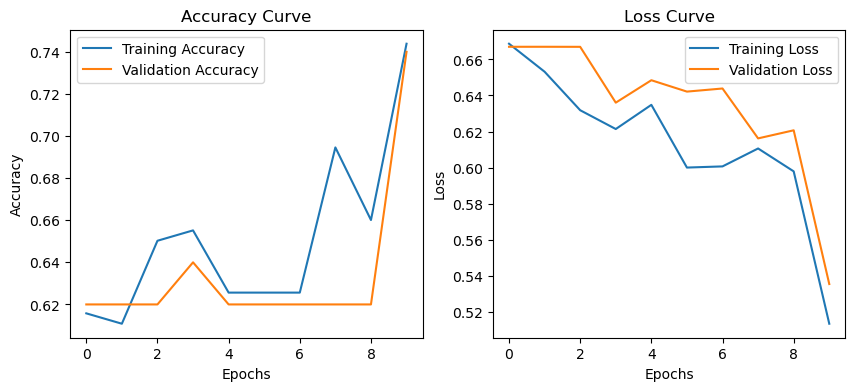

In [28]:
# =========================================
# PLOT ACCURACY + LOSS
# =========================================
plot_history = final_history if "final_history" in globals() else history_adam

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(plot_history.history['accuracy'],label="Training Accuracy")
plt.plot(plot_history.history['val_accuracy'],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(plot_history.history['loss'],label="Training Loss")
plt.plot(plot_history.history['val_loss'],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.show()

In [29]:
# =========================================
# TRANSFER LEARNING (VGG16)
# =========================================
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])

transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining Transfer Learning Model (VGG16)")

transfer_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

Training Transfer Learning Model (VGG16)
Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.6059 - loss: 2.5809 - val_accuracy: 0.6800 - val_loss: 0.8840
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7537 - loss: 0.6571 - val_accuracy: 0.7600 - val_loss: 0.9981
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.7931 - loss: 0.5468 - val_accuracy: 0.8200 - val_loss: 0.5220
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8670 - loss: 0.3721 - val_accuracy: 0.8400 - val_loss: 0.3871
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.8276 - loss: 0.3499 - val_accuracy: 0.8600 - val_loss: 0.3339
